<div align="center">
    <font color="0F5298" size="7">
        Deep Learning <br>
    </font>
    <font color="2565AE" size="5">
        CE Department <br>
        Spring 2024 - Prof. Soleymani Baghshah <br>
    </font>
    <font color="3C99D" size="5">
        HW2 Practical <br>
    </font>
    <font color="696880" size="5">
        30 Points
    </font>
</div>


In [39]:
FULLNAME = 'Mohammadreza koohi'
STD_ID = '402207199'

In this notebook, we aim to perform **classification** on images from the **CIFAR10** dataset using CNN networks. First, we load the dataset and apply the necessary transformations for normalization and augmentation. After that, we visualize some samples. Once we familiarize ourselves with the dataset, we proceed to design the desired convolutional network, which is explained in the relevant section. After designing the model, we move on to training and evaluating it. At the end of the first section, we analyze the feature space from different perspectives. First, using the KNN method, we examine the closest samples to each other in the feature space. Then, we cluster the data and finally visualize the outputs of the intermediate layers of the model.

In the second part of the notebook, we perform a simple transfer learning task on the trained model from the first section but using a new dataset, **CIFAR100**. To do this, we modify the final layer of the network and retrain it. Further details are provided in the relevant section. Finally, we evaluate the model’s accuracy on the new task and analyze the extracted features and how well the model generalizes. After designing and training the model, we will further analyze the extracted feature space. Finally, we will evaluate the generalization ability of the model and its extracted features on a new dataset,

# CIFAR10 Classification

## Import Libraries

Import needed libraries

In [4]:
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from torch import nn
import torch.nn.functional as F
import tqdm
from time import time
import random
from sklearn.manifold import TSNE
import numpy as np
from random import sample
import math
import torch.optim as optim
import seaborn as sns
from sklearn.metrics.pairwise import cosine_distances

## Device

Set device to work with (GPU or CPU)

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Transforms & Dataset & Dataloader

Here, you should download and load the dataset with the desire transforms. After that, you should split train dataset to train and validation sets. Finally, define the dataloaders for `train`, `validation` and `test`

In [6]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [7]:
# TODO: Data Transforms

from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.1))
])

# TODO: Load Train Data
dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
# TODO: Split Train and Validation Data

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# TODO: Load Test Data

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
# TODO: Define Data Loaders

train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True, num_workers=8)
val_loader = DataLoader(val_dataset, batch_size=100, shuffle=False, num_workers=8)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False, num_workers=8)


## Visualization

Visualize 5 random images from each class in different columns

- **Hint**:  You can use `plt.subplots` for visualization

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.110384].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.9059559].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6903974..2.0942786].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1264887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0459638].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0432324].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737

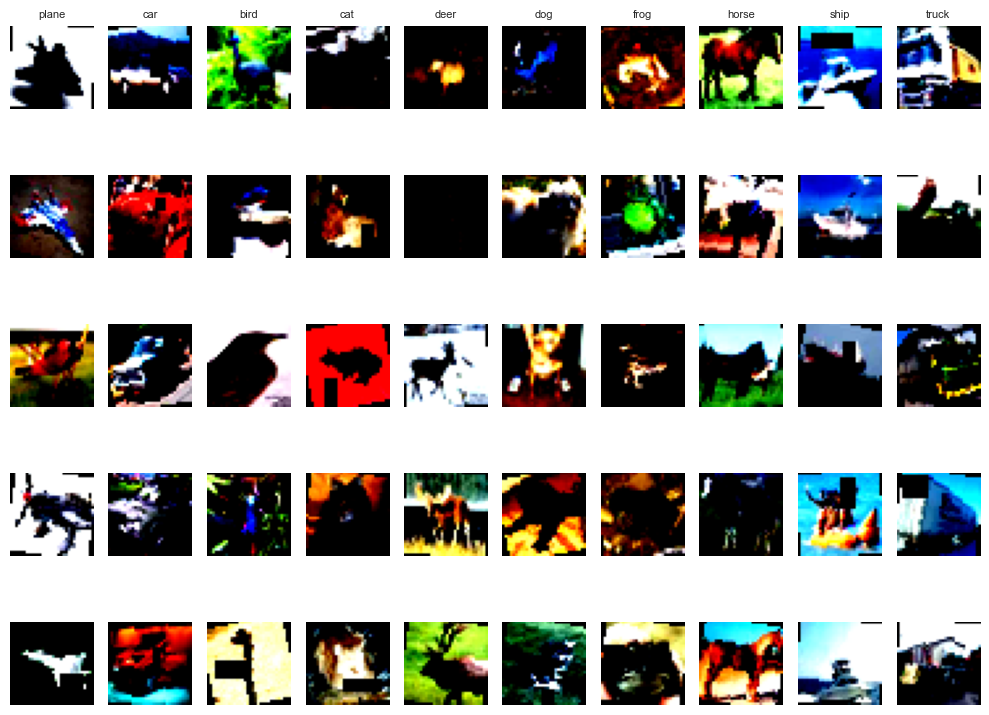

In [8]:
# TODO: Find 5 Images from Each Class
class_images = {class_idx: [] for class_idx in range(10)}

for img, label in dataset:
    if len(class_images[label]) < 5:
        class_images[label].append(img.permute(1, 2, 0).numpy())

    if all(len(images) == 5 for images in class_images.values()):
        break

# Plot Images

fig, axes = plt.subplots(5, 10, figsize=(10, 8))

for col, (class_idx, images) in enumerate(class_images.items()):
    for row in range(5):
        axes[row, col].imshow(images[row])
        axes[row, col].axis("off")

for col, class_name in enumerate(classes):
    axes[0, col].set_title(class_name, fontsize=8)

plt.tight_layout()
plt.show()

## Model

Define your model here from scratch (You are not allowed to use the existing models in pytorch)

**NOTICE:** The model that you will have defined outputs a vector containing 10 numbers (for each class). Define a "feature space" that is a vector of size *N* (where *N > 10*) right before the last layer (You can then have a last layer like `nn.Linear(N, 10)`). See the image below to get a better understanding. We will use this later (we want to access the feature space of a sample when the sample is given to the model). The model tries to learn a representation of the samples in this feature space and we will see how good it could do this in later sections.

![Feature Space In Neural Network](https://i.postimg.cc/28Qjcn9D/feature-space-vis.png)

- **Hint I**: Our goal is to get accuracy above *90%* on testset. Our suggestion is to implement ResNet (ResNet18 could be a viable choice)
  - You can learn the network's structure and implementation online (Youtube, ...) and then implmenet it yourself and make changes to enhance it's performance on our task **(YOU SHOULD NOT COPY THE CODE!!! OTHERWISE, YOU'LL BE PENALIZED!!!)**

- **Hint II**: When defining your model, pay attension to the **NOTICE** part in the above. It's also better to read the "Exploring the feature space" section beforehand.

In [2]:
# TODO: Implement Model
# تو یوتوب  یک ویدیو بود که از اون استفاده کردم برای پیاده سازی و ی سایت دیگه توضیح داده بود expansion را باید برای مدل های کم عمق 1 و برای مدل های عمیق 4 گذاشت منم برای راحتی کار دوتا مدل تعریف کردم .

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, identity_downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.identity_downsample = identity_downsample
        # self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        identity = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)
        x += identity
        x = self.relu(x)
        # x = self.dropout(x)
        return x

class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, identity_downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, stride=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.relu = nn.ReLU()
        self.identity_downsample = identity_downsample

    def forward(self, x):
        identity = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.conv3(x)
        x = self.bn3(x)
        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)
        x += identity
        x = self.relu(x)
        return x

class ResNet(nn.Module):
    def __init__(self, block, layers, image_channels=3, num_classes=10):
        super().__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(image_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()

        self.maxpool = nn.Identity()

        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512 * block.expansion, num_classes)
        )

    def _make_layer(self, block, out_channels, blocks, stride):
        identity_downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            identity_downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion)
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, identity_downsample))
        self.in_channels = out_channels * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)

        x = self.fc(x)
        return x


def ResNet18(img_channels=3, num_classes=10):
    return ResNet(BasicBlock, [2, 2, 2, 2], img_channels, num_classes)

def ResNet50(img_channels=3, num_classes=10):
    return ResNet(Bottleneck, [3, 4, 6, 3], img_channels, num_classes)



## Train

### Model instantiation

Create an instance of your model and move it to `device`

In [9]:
# TODO: Define Model
model = ResNet18(img_channels=3, num_classes=10)
model = model.to(device)
model.train()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, e

### Criterion & Optimizater

Define `criterion` and `optimizer` (Or `scheduler`)

In [10]:
# TODO: Define Loss and Optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.0001,
    momentum=0.9,
    weight_decay=2e-3
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=200
)

### Train loop

Train your model

Tasks:
- [ ] Things that are needed to be printed in each epoch:
  - Number of epoch
  - Train loss
  - Train accuracy
  - Validation loss
  - Validation accuracy
- [ ] save train/validation loss and accuracy (of each epoch) in an array for later usage

In [10]:
# TODO: Implement Training Loop
def train_loop(model, train_loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # محاسبه دقت
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    return train_loss, train_accuracy


In [11]:
# TODO: Implement Validation Loop
def validation_loop(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_accuracy = 100 * val_correct / val_total
    val_loss = val_loss / len(val_loader)

    return val_loss, val_accuracy

In [13]:
train_loss_list = []
train_accuracy_list = []
val_loss_list = []
val_accuracy_list = []

In [16]:
# TODO: Train The Modeldef train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs, device):

def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs, device):

    best_val_acc = 0.0

    for epoch in range(num_epochs):
        start_time = time()
        print(f"Epoch [{epoch+1}/{num_epochs}]")


        train_loss, train_accuracy = train_loop(model, train_loader, optimizer, criterion, device)
        train_loss_list.append(train_loss)
        train_accuracy_list.append(train_accuracy)
        scheduler.step()

        val_loss, val_accuracy = validation_loop(model, val_loader, criterion, device)
        val_loss_list.append(val_loss)
        val_accuracy_list.append(val_accuracy)
        end_time = time()


        print(f'Epoch {epoch + 1:3} finished in {end_time - start_time:.2f}s')
        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            print('saving best model')
            torch.save(model.state_dict(), 'best_model.pth')

    return train_loss_list, train_accuracy_list, val_loss_list, val_accuracy_list

train_loss, train_accuracy, val_loss, val_accuracy = train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=20, device=device)

Epoch [1/20]
Epoch   1 finished in 58.10s
Train Loss: 0.5344, Train Accuracy: 99.53%
Validation Loss: 0.8290, Validation Accuracy: 86.67%
saving best model
Epoch [2/20]
Epoch   2 finished in 58.13s
Train Loss: 0.5337, Train Accuracy: 99.52%
Validation Loss: 0.8229, Validation Accuracy: 86.74%
saving best model
Epoch [3/20]
Epoch   3 finished in 57.94s
Train Loss: 0.5324, Train Accuracy: 99.57%
Validation Loss: 0.8209, Validation Accuracy: 87.15%
saving best model
Epoch [4/20]
Epoch   4 finished in 57.96s
Train Loss: 0.5320, Train Accuracy: 99.52%
Validation Loss: 0.8121, Validation Accuracy: 87.19%
saving best model
Epoch [5/20]
Epoch   5 finished in 57.92s
Train Loss: 0.5313, Train Accuracy: 99.59%
Validation Loss: 0.8140, Validation Accuracy: 87.03%
Epoch [6/20]
Epoch   6 finished in 57.99s
Train Loss: 0.5301, Train Accuracy: 99.62%
Validation Loss: 0.8163, Validation Accuracy: 87.01%
Epoch [7/20]
Epoch   7 finished in 58.01s
Train Loss: 0.5318, Train Accuracy: 99.53%
Validation Loss

 ### Save Model

Since changes need to be made to the model later on, it is advisable to save your model to avoid having to retrain it in case of any issues.

In [18]:
# TODO: Save Model
# بهترین مدل را در سلول بالا ذخیره کردم
def save_model(model, path):
    torch.save(model.state_dict(), path)
    print(f"Model saved to {path}")

save_model(model, 'model.pth')

Model saved to model.pth


### Visualize Loss and Accuracy plot

Using the arrays that you have (from task 2 in the above section), visualize two plots: Accuracy plot (train and validation together) and Loss plot (train and validation together)

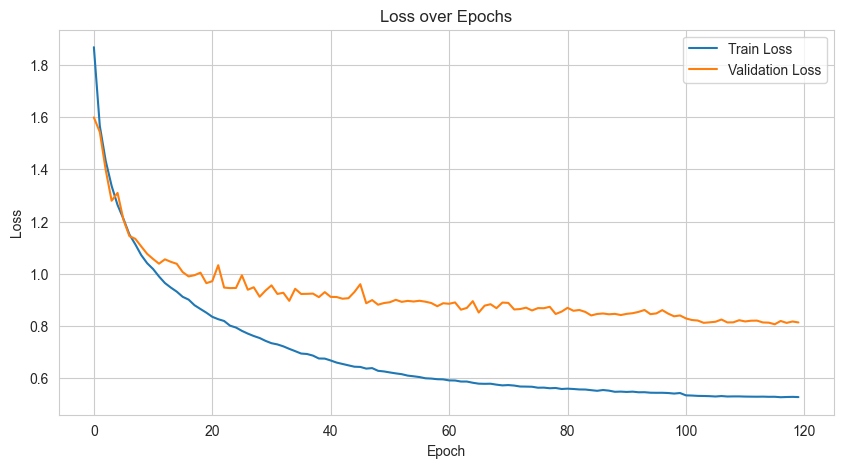

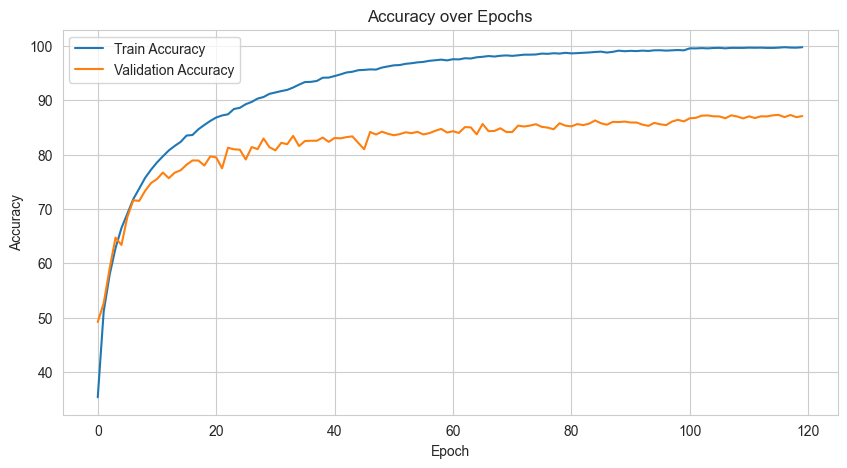

In [19]:
import matplotlib.pyplot as plt

# TODO: Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# TODO: Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(train_accuracy_list, label='Train Accuracy')
plt.plot(val_accuracy_list, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


## Evaluation

Test your trained model (using the Test Dataloader that you have). Our goal is to reach an accuracy above `90%`

In [15]:
model.load_state_dict(torch.load('best_model.pth', map_location=torch.device(device)))
model = model.to(device)
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy on test set: {accuracy:.2f}%')


Accuracy on test set: 90.98%


## Visualize incorrectly predicted samples from testset

Visualize *24* random images from testset that are incorrectly predicted by the model. Note that if you used normalization in the transform function for loading the data, you will need to unnormalize the images before displaying them.

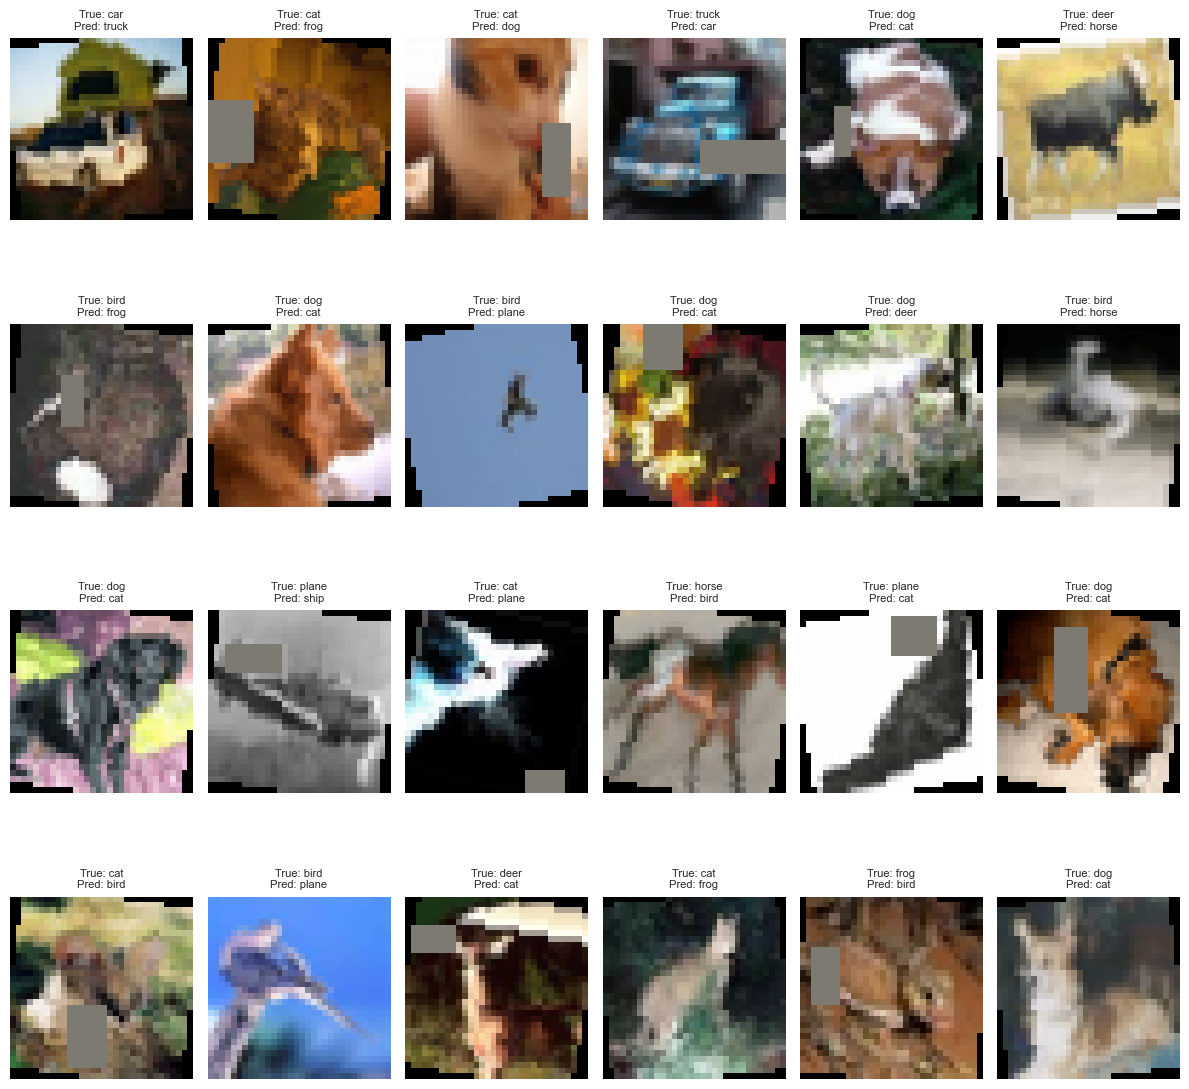

In [16]:
# TODO: Plot Samples with Wrong Predicted Classes

def unnormalize(img_tensor):
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    img = img_tensor.cpu().numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img


wrong_images = []
true_labels = []
predicted_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        for i in range(len(labels)):
            if preds[i] != labels[i]:
                wrong_images.append(inputs[i].cpu())
                true_labels.append(labels[i].item())
                predicted_labels.append(preds[i].item())


num_images = 24
indices = random.sample(range(len(wrong_images)), min(num_images, len(wrong_images)))


plt.figure(figsize=(12, 12))
for i, idx in enumerate(indices):
    img = unnormalize(wrong_images[idx])
    true_label = classes[true_labels[idx]]
    pred_label = classes[predicted_labels[idx]]

    plt.subplot(4, 6, i + 1)
    plt.imshow(img)
    plt.title(f'True: {true_label}\nPred: {pred_label}', fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()



## Exploring the feature space

### Calculate the feature space for all training samples

You have trained and evaluated your model. Now, for each sample in the trainset, calculate it's "feature space" discussed in the model section. The result of this section should be a tensor of size `(50000, N)` saved in a variable (for later usage)

- **Hint 1:** define a tensor with dimension `(50000, N)` where *50000* is the size of the trainset and *N* is the dimension of the feature space

- **Hint 2:** Pay attension to the `shuffle` attribute of your train dataloader (If needed)

In [17]:
# TODO: Find Features and Put Them in One Dimensional List
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=False)

model = ResNet18().to(device)
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

feature_list = []

def hook_fn(module, input, output):
    feature_list.append(output.detach().cpu())

hook = model.avgpool.register_forward_hook(hook_fn)

with torch.no_grad():
    for inputs, _ in train_loader:
        inputs = inputs.to(device)
        _ = model(inputs)

hook.remove()

features = torch.cat(feature_list, dim=0)

features = features.view(features.size(0), -1)

### K Nearest Neighbor in feature space

You already have calculated the feature spaces for trainset ($S$) in the previous section

1. Get 5 random samples from testset which are correctly predicted by the model.
2. for each sample, calculate it's "feature space" ($X$)
3. for each sample, calculate it's *5* nearest neighbors in "feature space" in the trainset (by comparing $X$ to each row in $S$) and visualize them

**Note:** Your visualization should be something like the below picture

**Hint:** To find the nearest neighbors in the feature space, you can use any library of your choice.

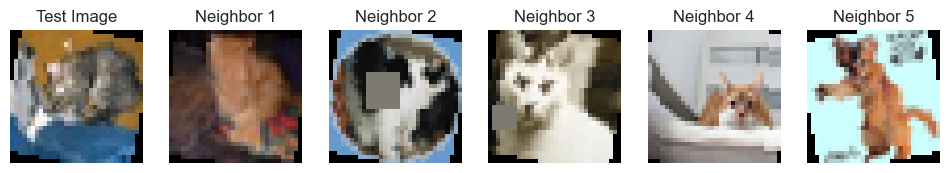

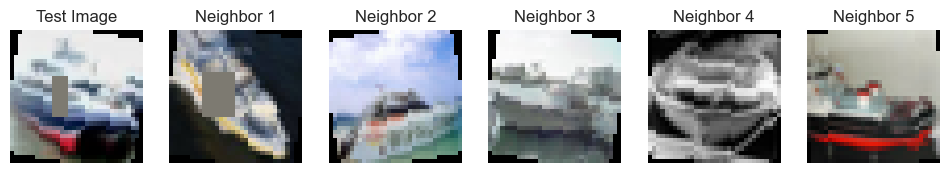

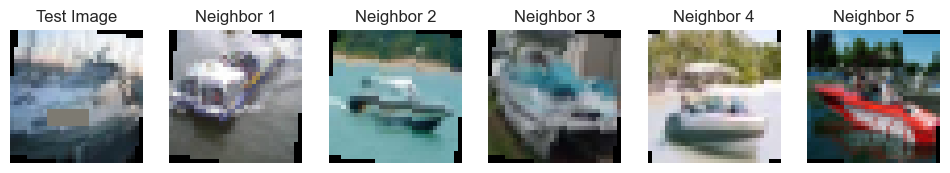

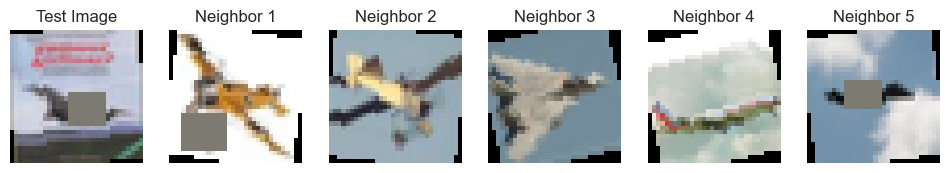

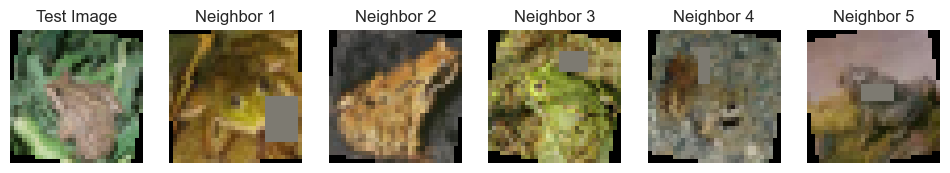

In [18]:
# TODO: Find Features List for Test Samples

feature_list_train = []

def hook_fn_train(module, input, output):
    feature_list_train.append(output.view(output.size(0), -1).detach().cpu())

hook_train = model.avgpool.register_forward_hook(hook_fn_train)

model.eval()
with torch.no_grad():
    for idx, (inputs, labels) in enumerate(train_loader):
        inputs = inputs.to(device)
        outputs = model(inputs)

        if len(feature_list_train) >= 2000:
            break

hook_train.remove()
features_train = torch.cat(feature_list_train, dim=0)

# Find K Nearest Features

correct_samples = []
correct_features = []
feature_list_test = []

def hook_fn_test(module, input, output):
    feature_list_test.append(output.view(output.size(0), -1).detach().cpu())

hook_test = model.avgpool.register_forward_hook(hook_fn_test)

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        preds = outputs.argmax(dim=1)
        features = feature_list_test[-1]

        for i in range(inputs.size(0)):
            if preds[i] == labels[i]:
                correct_samples.append(inputs[i].cpu())
                correct_features.append(features[i])
                if len(correct_samples) == 5:
                    break

        if len(correct_samples) == 5:
            break

hook_test.remove()
correct_features = torch.stack(correct_features, dim=0)


def get_k_nearest_neighbors(test_feat, train_feats, k=5):
    test_feat = test_feat.unsqueeze(0).cpu().numpy()
    train_feats = train_feats.cpu().numpy()
    distances = cosine_distances(test_feat, train_feats)
    nearest = distances.squeeze().argsort()[:k]
    return nearest

def unnormalize(img):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    return img * std + mean


# Plot Features' Images

def plot_neighbors(test_imgs, test_feats, train_feats, train_dataset):
    for i in range(5):
        neighbors_idx = get_k_nearest_neighbors(test_feats[i], train_feats)

        plt.figure(figsize=(12, 2))
        for j in range(6):
            plt.subplot(1, 6, j + 1)
            if j == 0:
                img = unnormalize(test_imgs[i])
                title = 'Test Image'
            else:
                idx = neighbors_idx[j - 1].item()
                img, _ = train_dataset[idx]
                img = unnormalize(img)
                title = f'Neighbor {j}'

            plt.imshow(img.permute(1, 2, 0).cpu().numpy())
            plt.title(title)
            plt.axis('off')
        plt.show()

plot_neighbors(correct_samples, correct_features, features_train, train_dataset)


### TSNE

1. Sample $M$ ($2000$ would be enought) random samples from the trainset feature space (calculated in the above sections)
2. Now you a vector of size `(M, N)` where $N$ is the dimension of the feature space
3. Using TSNE reduce $N$ to $2$ (Now you have a vector of size `(M, 2)`)
4. Print the shape of the output

**Hint:** You can use `sklearn.manifold.TSNE`

In [19]:
# TODO: Get Samples
M = 2000
total = len(train_dataset)

if total < M:
    M = total
    print(f"⚠ Only {M} samples available. Sampling all of them.")

random_indices = random.sample(range(total), M)

sampled_inputs = torch.stack([train_dataset[i][0] for i in random_indices]).to(device)
sampled_labels = [train_dataset[i][1] for i in random_indices]


# TODO: Use TSNE
features_list = []

def hook_fn(module, input, output):
    features_list.append(output.view(output.size(0), -1).detach().cpu())

hook = model.avgpool.register_forward_hook(hook_fn)

model.eval()
with torch.no_grad():
    _ = model(sampled_inputs)

hook.remove()

features_tensor = torch.cat(features_list, dim=0)
features_np = features_tensor.numpy()

tsne = TSNE(n_components=2, random_state=42)
reduced_2d = tsne.fit_transform(features_np)



Visualize the points in a 2D plane (Set color of each point based on it's class)

**Notice:** Your visualization should be something like the below image

**Hint:** Use `plt.scatter(x, y, c=labels)`

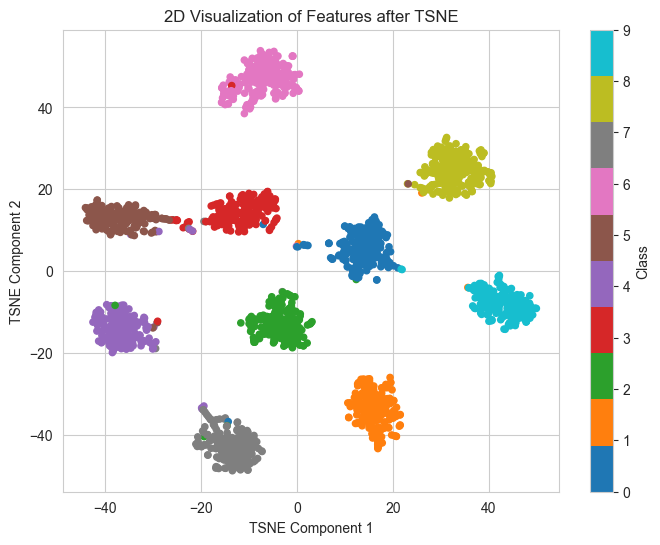

In [20]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(reduced_2d[:, 0], reduced_2d[:, 1], c=sampled_labels, cmap='tab10', s=20)
plt.colorbar(scatter, label='Class')
plt.title('2D Visualization of Features after TSNE')
plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.show()


### Feature Map


In this part, we are going to visualize the output of one of the convolutional layers to see what features they focus on.

First, let's select a random image from dataset.

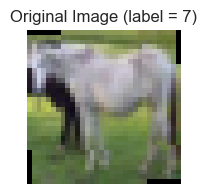

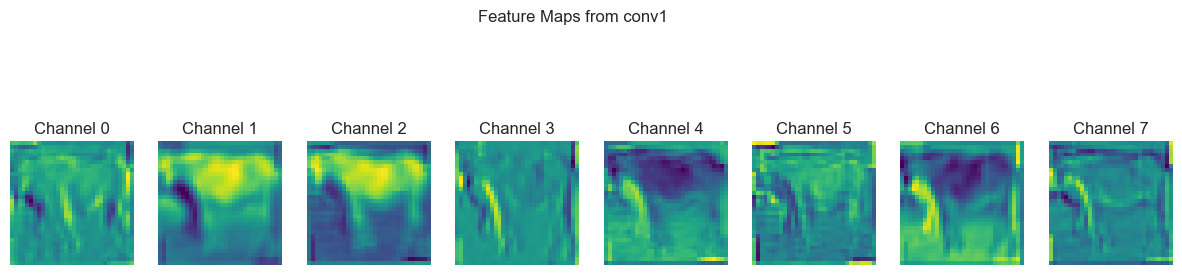

In [23]:
# TODO: Select an Image


random_idx = random.randint(0, len(test_dataset) - 1)
img, label = test_dataset[random_idx]
input_tensor = img.unsqueeze(0).to(device)

def unnormalize(img):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    return img * std + mean

plt.figure(figsize=(2, 2))
plt.imshow(unnormalize(img).permute(1, 2, 0).cpu().numpy())
plt.title(f"Original Image (label = {label})")
plt.axis('off')
plt.show()

activation = []
def hook_fn(module, input, output):
    activation.append(output.detach().cpu())

hook = model.conv1.register_forward_hook(hook_fn)

model.eval()
with torch.no_grad():
    _ = model(input_tensor)

hook.remove()

feature_map = activation[0].squeeze(0)
num_channels_to_show = 8
plt.figure(figsize=(15, 4))
for i in range(num_channels_to_show):
    plt.subplot(1, num_channels_to_show, i + 1)
    plt.imshow(feature_map[i], cmap='viridis')
    plt.title(f'Channel {i}')
    plt.axis('off')

plt.suptitle("Feature Maps from conv1")
plt.show()


Now, we are going to *clip* our model at different points to get different intermediate representation.
* Clip your model at least at one point and plot the filters output. You can use the output of first Resnet block.

In order to clip the model, you can use `model.children()` method. For example, to get output only after the first 2 layers, you can do:

```
clipped = nn.Sequential(
    *list(model.children()[:2])
)
intermediate_output = clipped(input)
```



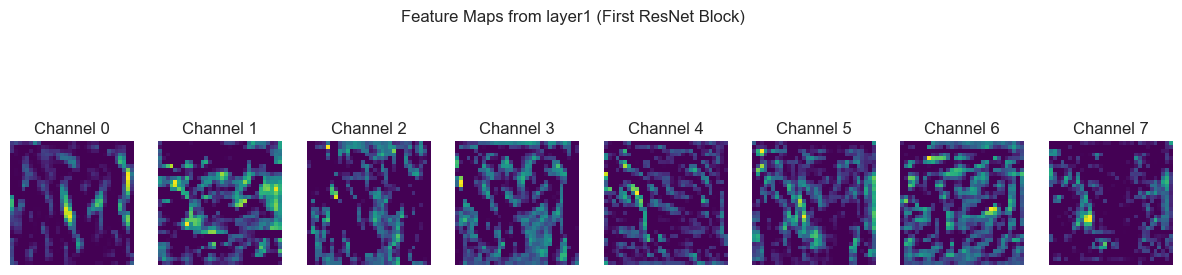

In [24]:
# TODO: Get Intermediate Output

import torch.nn as nn

clipped_model = nn.Sequential(
    *list(model.children())[:5]  # [conv1, bn1, relu, maxpool, layer1]
).to(device)

model.eval()
with torch.no_grad():
    intermediate_output = clipped_model(input_tensor)  # shape: (1, C, H, W)

intermediate_feature_map = intermediate_output.squeeze(0).cpu()  # shape: (C, H, W)

num_channels_to_show = 8
plt.figure(figsize=(15, 4))
for i in range(num_channels_to_show):
    plt.subplot(1, num_channels_to_show, i + 1)
    plt.imshow(intermediate_feature_map[i], cmap='viridis')
    plt.title(f'Channel {i}')
    plt.axis('off')
plt.suptitle("Feature Maps from layer1 (First ResNet Block)")
plt.show()


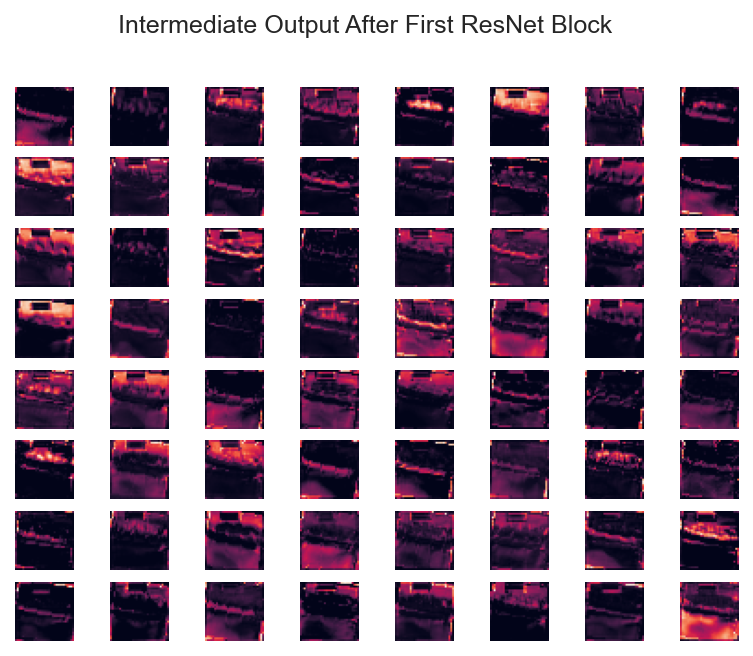

In [13]:
def plot_intermediate_output(result, title=None):
    plt.rcParams['figure.dpi'] = 150
    n_filters = result.shape[1]
    N = int(math.sqrt(n_filters))
    M = (n_filters + N - 1) // N
    assert N * M >= n_filters

    fig, axs = plt.subplots(N, M)
    fig.suptitle(title)

    for i in range(N):
        for j in range(M):
            if i*N + j < n_filters:
                axs[i][j].imshow(result[0, i*N + j].cpu().detach())
                axs[i][j].axis('off')

# TODO: Plot Intermediate Output

model.eval()
with torch.no_grad():
    intermediate_output = clipped_model(input_tensor)

plot_intermediate_output(intermediate_output, title="Intermediate Output After First ResNet Block")

clipped_model = nn.Sequential(*list(model.children())[:6])


## CIFAR100

In this section, we aim to test the trained model on a different dataset. For this purpose, we will use the CIFAR100 dataset, which is similar to CIFAR10 but has different types and numbers of classes. In order for the model to perform well on the new dataset, we need to modify the last layer of the model. As you know from the previous section, the last layer of the model is a linear layer that maps the features to the number of classes. In this section, due to the increase in the number of classes, we plan to modify this layer and train the new linear layer with the new dataset. Note that all other layers and weights of the model will remain fixed and unchanged; only the last layer will be retrained.

### Dataset & Dataloader

Here, you should download and load the dataset with the desire transforms.

In [26]:
# TODO: Data Transforms
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.02
    ),
    transforms.RandomApply([
        transforms.RandomRotation(5)
    ], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5071, 0.4867, 0.4408],
        std=[0.2675, 0.2565, 0.2761]
    ),
    transforms.RandomErasing(
        p=0.3,
        scale=(0.02, 0.15),
        ratio=(0.3, 3.3)
    ),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3)
    ], p=0.2)
])


transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5071, 0.4867, 0.4408],
        std=[0.2675, 0.2565, 0.2761]
    )
])

# TODO: Load Train and Test Data
train_dataset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

# TODO: Define Data Loaders
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True, num_workers=8)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False, num_workers=8)


In [27]:
classes = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee",
    "beetle", "bicycle", "bottle", "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle", "chair", "chimpanzee",
    "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur", "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster",
    "house", "kangaroo", "keyboard", "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain", "mouse",
    "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree", "plain", "plate", "poppy", "porcupine", "possum",
    "rabbit", "raccoon", "ray", "road", "rocket", "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor", "train",
    "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]
print(len(classes))

100


### Visualization

Visualize 1 random images from each class.

- **Hint**:  You can use `plt.subplots` for visualization

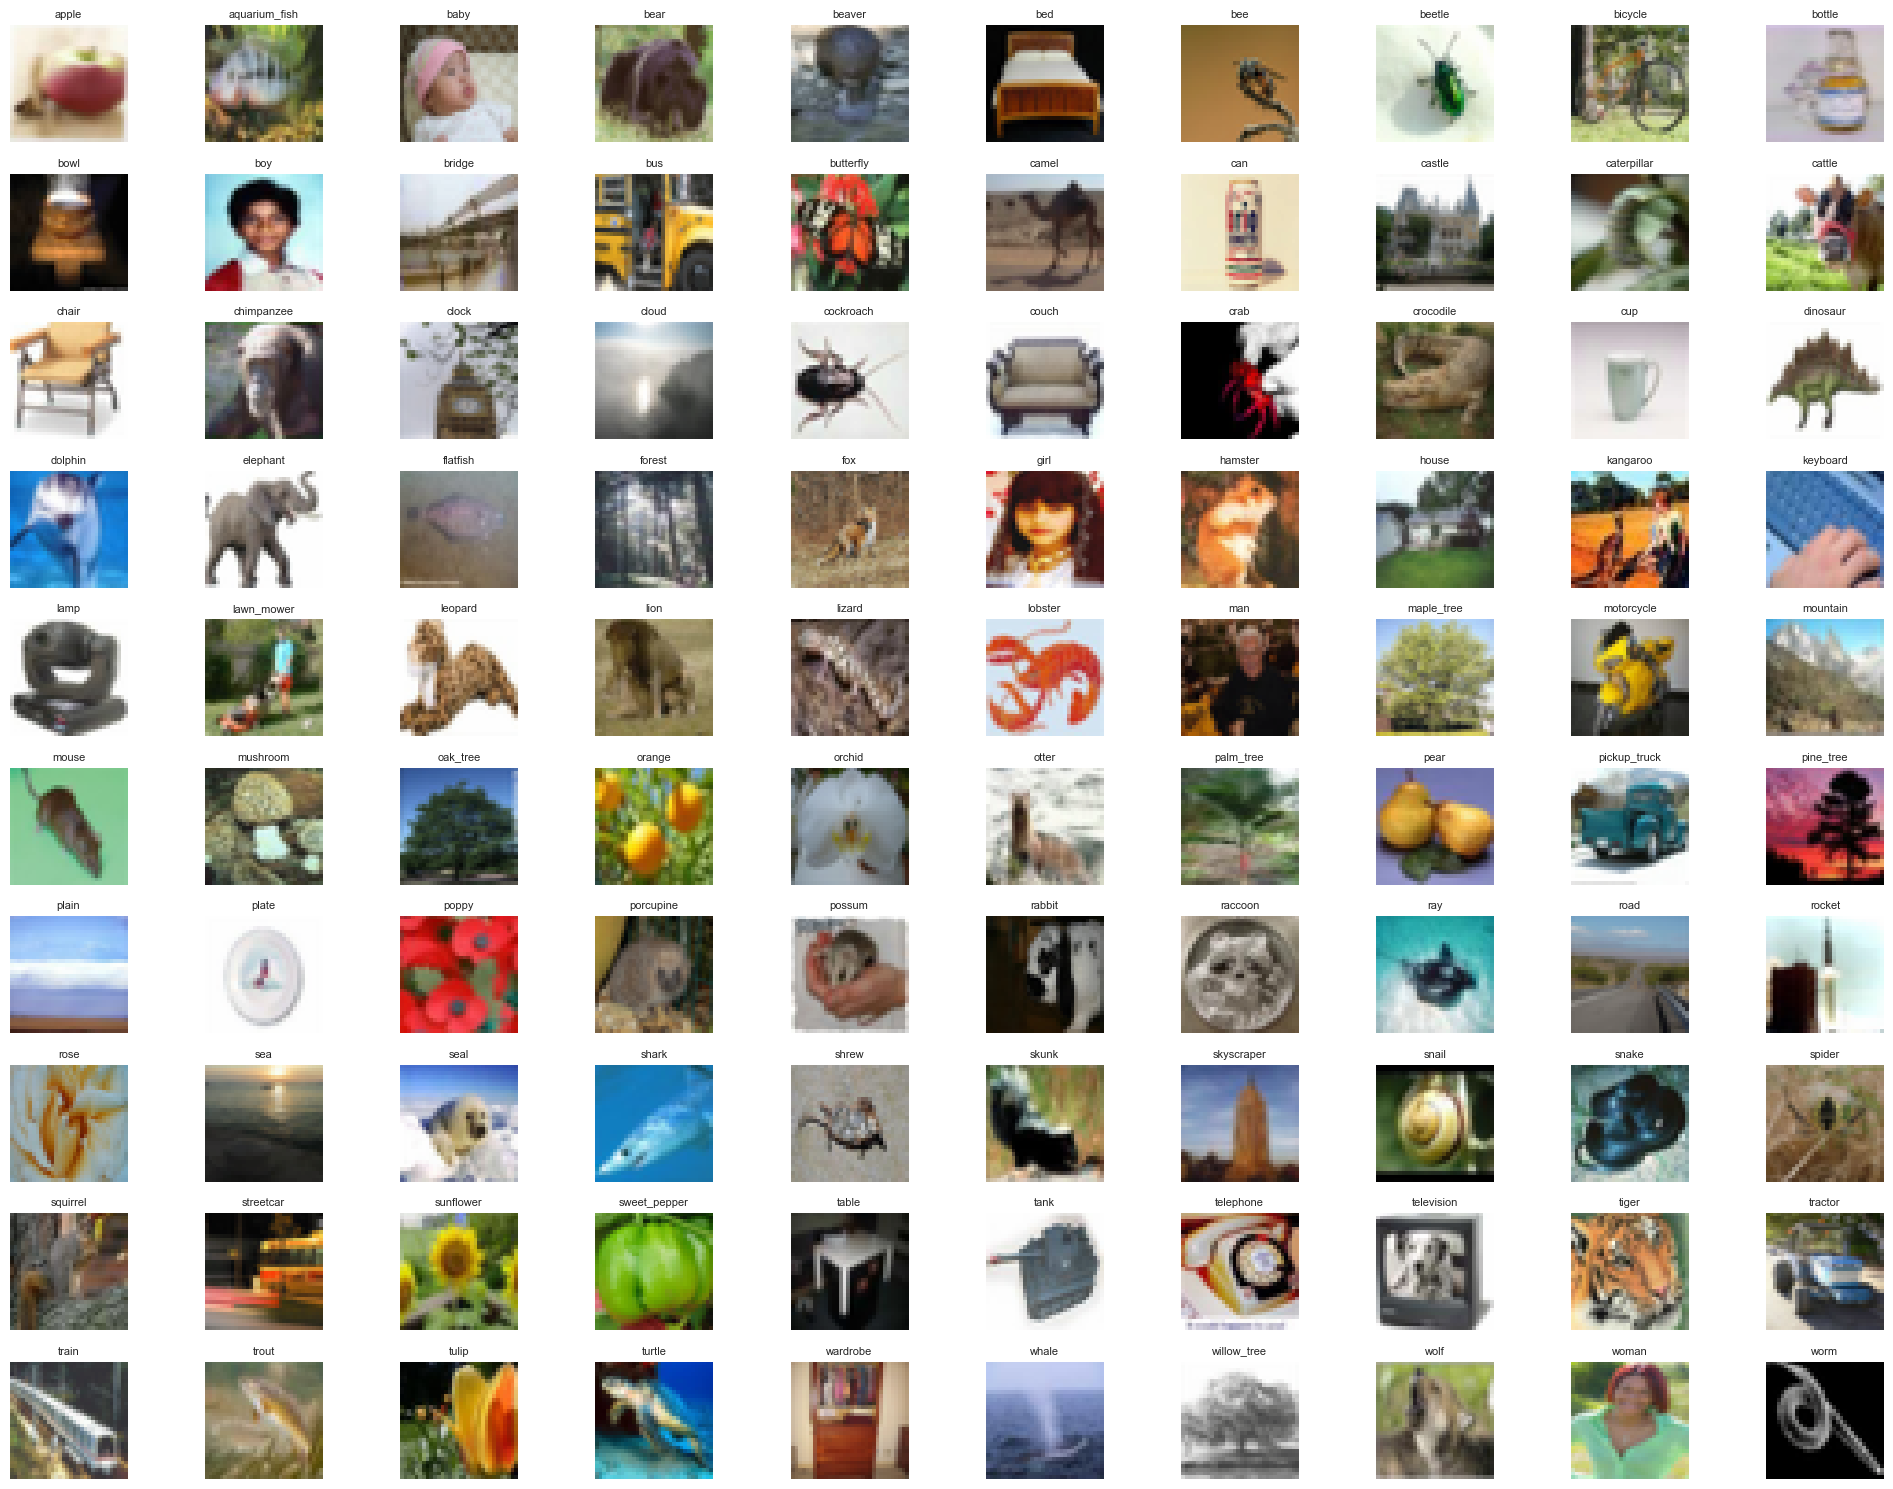

In [28]:
# TODO: Find One Image from Each Class
sampled_images = {}
sampled_labels = {}

raw_dataset = torchvision.datasets.CIFAR100(root='./data', train=True, download=False, transform=transform_test)

for img, label in raw_dataset:
    class_name = classes[label]
    if class_name not in sampled_images:
        sampled_images[class_name] = img
        sampled_labels[class_name] = label
    if len(sampled_images) == len(classes):
        break

sorted_class_names = sorted(sampled_images.keys())
sorted_images = [sampled_images[name] for name in sorted_class_names]

n_cols = 10
n_rows = int(np.ceil(len(sorted_images) / n_cols))

def denormalize(img):
    mean = np.array([0.5071, 0.4867, 0.4408])
    std = np.array([0.2675, 0.2565, 0.2761])
    img = img.numpy().transpose(1, 2, 0)
    img = std * img + mean
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15))
for i, ax in enumerate(axes.flat):
    if i < len(sorted_images):
        img = denormalize(sorted_images[i])
        ax.imshow(img)
        ax.set_title(sorted_class_names[i], fontsize=8)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()



### Modify Model

Change the final linear layer of the model according to the new number of classes And freeze all other layers.
- Do not forgot to move model to `device`

In [29]:
# Load Pretrained Model
# Move Model to Device

model = ResNet18(img_channels=3, num_classes=10)
state_dict = torch.load('best_model.pth', map_location=device)
model.load_state_dict(state_dict, strict=False)

for param in model.parameters():
    param.requires_grad = False

in_features = model.fc[1].in_features

model.fc = nn.Sequential(
    nn.Linear(in_features, 1024),
    nn.BatchNorm1d(1024),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(1024, 512),
    nn.BatchNorm1d(512),
    nn.GELU(),
    nn.Dropout(0.25),
    nn.Linear(512, 256),
    nn.LayerNorm(256),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(256, 100)
)
# Modify The Last Linear Layer
# Freeze All Layers

def init_weights(m):
    if isinstance(m, nn.Linear):
        if m.out_features == 100:
            nn.init.xavier_uniform_(m.weight, gain=nn.init.calculate_gain('relu'))
        else:
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')

model.fc.apply(init_weights)

for param in model.fc.parameters():
    param.requires_grad = True


### Criterion & Optimizater

Define `criterion` and `optimizer` (Or `scheduler`)

In [30]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    model.fc.parameters(),
    lr=0.001,
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.01,
    steps_per_epoch=len(train_loader),
    epochs=200,
    pct_start=0.2,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1000
)

In [14]:
torch.cuda.empty_cache()

### Train

Train the Model (Only Last Layer)

In [18]:
model.train()
def train_model(model, train_loader, criterion, optimizer, scheduler, num_epochs=10, device=None):
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    loss_history = []
    acc_history = []

    best_acc = 0.0
    best_model_path = "best_model_c100.pth"

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_samples = 0

        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            running_corrects += (preds == labels).sum().item()
            total_samples += labels.size(0)

        epoch_loss = running_loss / total_samples
        epoch_acc = running_corrects / total_samples * 100

        loss_history.append(epoch_loss)
        acc_history.append(epoch_acc)

        print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

        scheduler.step(epoch_loss)

        if epoch_acc > best_acc:
            best_acc = epoch_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"✅ Best model saved with accuracy: {best_acc:.2f}%")

    print("Training Finished.")
    print(f"🏆 Best Training Accuracy: {best_acc:.2f}%")
    return loss_history, acc_history



train_model(
    model=model,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=400,
    device=device
)


Epoch 1/400 - Loss: 3.4654, Accuracy: 20.62%
✅ Best model saved with accuracy: 20.62%
Epoch 2/400 - Loss: 3.4681, Accuracy: 20.43%
Epoch 3/400 - Loss: 3.4679, Accuracy: 20.37%
Epoch 4/400 - Loss: 3.4662, Accuracy: 20.67%
✅ Best model saved with accuracy: 20.67%
Epoch 5/400 - Loss: 3.4575, Accuracy: 20.68%
✅ Best model saved with accuracy: 20.68%
Epoch 6/400 - Loss: 3.4585, Accuracy: 20.87%
✅ Best model saved with accuracy: 20.87%
Epoch 7/400 - Loss: 3.4605, Accuracy: 20.77%
Epoch 8/400 - Loss: 3.4715, Accuracy: 20.45%
Epoch 9/400 - Loss: 3.4691, Accuracy: 20.47%
Epoch 10/400 - Loss: 3.4573, Accuracy: 20.70%
Epoch 11/400 - Loss: 3.4612, Accuracy: 20.69%
Epoch 12/400 - Loss: 3.4629, Accuracy: 20.79%
Epoch 13/400 - Loss: 3.4551, Accuracy: 20.63%
Epoch 14/400 - Loss: 3.4601, Accuracy: 20.70%
Epoch 15/400 - Loss: 3.4547, Accuracy: 20.90%
✅ Best model saved with accuracy: 20.90%
Epoch 16/400 - Loss: 3.4547, Accuracy: 20.89%
Epoch 17/400 - Loss: 3.4537, Accuracy: 21.04%
✅ Best model saved wit

KeyboardInterrupt: 

### Test

Evaluate the Model on CIFAR-100 Test Set. 40% accuracy is sufficient.


In [19]:
# TODO: Evaluate Model on CIFAR100

# TODO: Print Accuracy

def evaluate_model(model, test_loader, device=None):
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy on the test set: {accuracy:.2f}%')
    return accuracy

accuracy = evaluate_model(model, test_loader)

Accuracy on the test set: 29.04%


### Question
You might think that 40% accuracy is quite low. However, first of all, consider that the classification is done over 100 classes. The accuracy of a random model in this case is 1%. Also, we only changed one linear layer of the model, and the rest of the weights remained unchanged. What do you think is the reason the model can achieve a reasonably good generalization ability on a completely new dataset with just the change of one linear layer at the end?

"جواب : چون وقتی ما فقط لایه اخر را عوض کردیم ، مدل موادری که قبلا اموخته بوده را هنوز به یاد دارد . مثلا لبه ها ، خطوط و... و در لایه های جلو تر الگو هایی مثل اشکال هندسی و تا وقتی که به الگو های کامل مثل چشم و ... می رسد  ، وقتی مدل ما از قبل این ها را اموخته  در لایه اخر از این موارد استفاده می کند تا به درستی کلاس مد نظر را تشخیص بدهد "

### Visualize incorrectly predicted samples from testset

Visualize *10* random images from testset that are incorrectly predicted by the model

Total wrong predictions: 7096


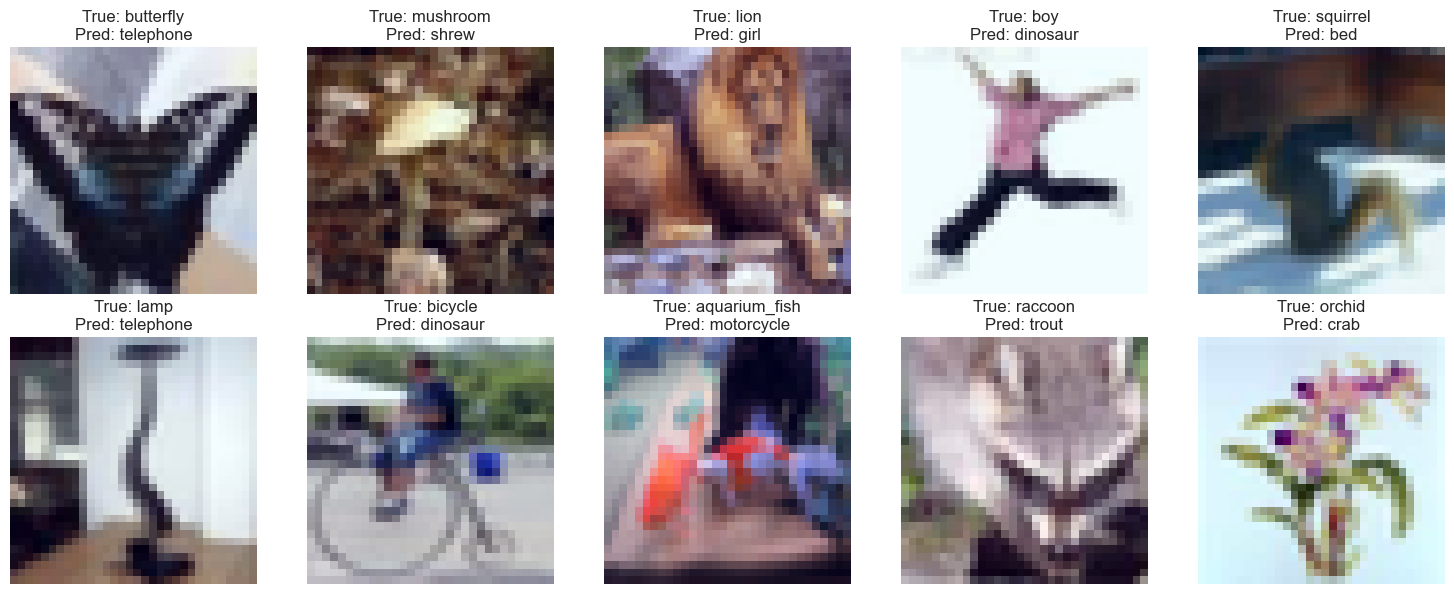

In [28]:
# TODO: Plot Samples with Wrong Predicted Classes

def visualize_wrong_predictions(model, test_loader, classes, device=None, num_samples=10):
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    model.to(device)

    wrong_samples = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for img, label, pred in zip(inputs, labels, preds):
                if pred != label:
                    wrong_samples.append((img.cpu(), label.item(), pred.item()))

    print(f"Total wrong predictions: {len(wrong_samples)}")

    if len(wrong_samples) < num_samples:
        num_samples = len(wrong_samples)

    selected_samples = random.sample(wrong_samples, num_samples)

    plt.figure(figsize=(15, 6))
    for i, (img, true_label, pred_label) in enumerate(selected_samples):
        plt.subplot(2, 5, i + 1)
        img = img.permute(1, 2, 0)
        img = img.numpy()
        img = (img - img.min()) / (img.max() - img.min())

        plt.imshow(img)
        plt.title(f"True: {classes[true_label]}\nPred: {classes[pred_label]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

visualize_wrong_predictions(model, test_loader, classes)


### Plot accuracy for each class

Plot accuracy of model on testset for each class.

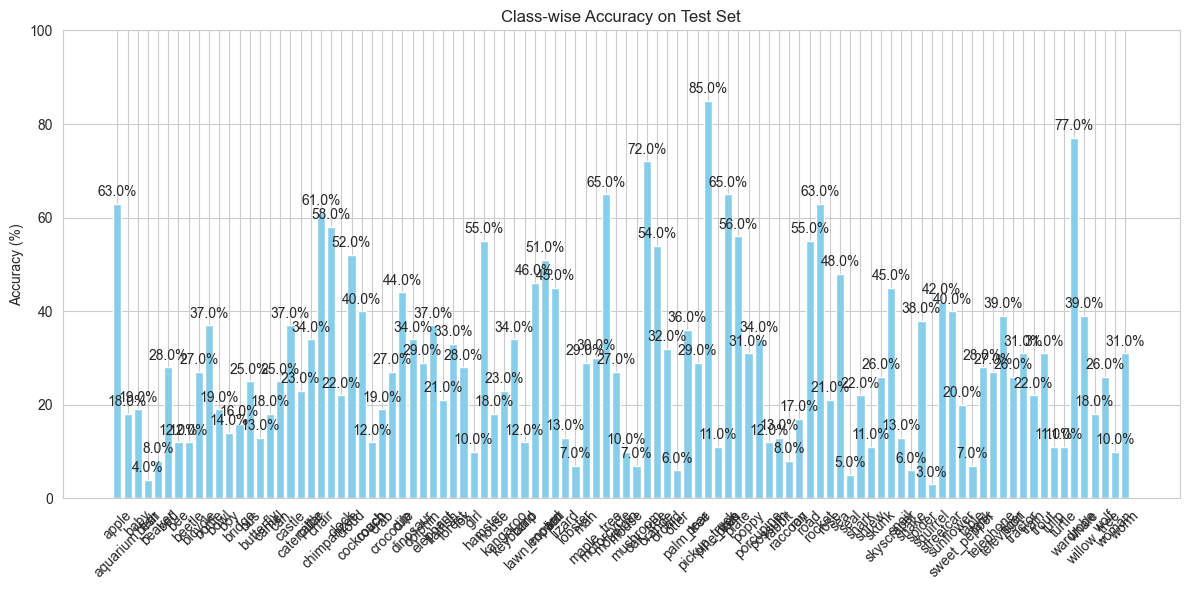

In [30]:

def plot_classwise_accuracy(model, test_loader, classes, device=None):
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    model.to(device)

    num_classes = len(classes)

    correct_per_class = [0] * num_classes
    total_per_class = [0] * num_classes

    # TODO: Calculate Accuracy for Each Class
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for label, pred in zip(labels, preds):
                total_per_class[label.item()] += 1
                if label == pred:
                    correct_per_class[label.item()] += 1

    acc_per_class = [100 * c / t if t > 0 else 0 for c, t in zip(correct_per_class, total_per_class)]

    # TODO: Plot Class-Wise Accuracy
    plt.figure(figsize=(12, 6))
    plt.bar(classes, acc_per_class, color='skyblue')
    plt.xticks(rotation=45)
    plt.ylabel('Accuracy (%)')
    plt.title('Class-wise Accuracy on Test Set')
    plt.ylim(0, 100)
    for i, acc in enumerate(acc_per_class):
        plt.text(i, acc + 1, f"{acc:.1f}%", ha='center', va='bottom')
    plt.tight_layout()
    plt.show()


plot_classwise_accuracy(model, test_loader, classes)


### The classes with the best and worst accuracy

Based on the results from the previous section, obtain the 5 classes with the best accuracy and the 5 classes with the worst accuracy on the testset, and display one sample from each of them.

Top 5 Best Performing Classes: [58 94 52 60 48]
Top 5 Worst Performing Classes: [80  3 72 55 78]


C:\Users\moham\AppData\Local\Temp\ipykernel_12688\2276535804.py:62: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) Arial.
  plt.tight_layout()


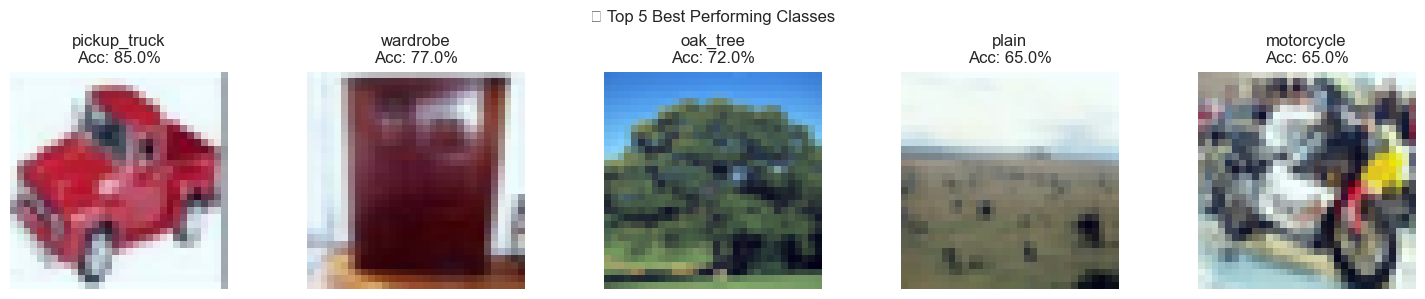

C:\Users\moham\AppData\Local\Temp\ipykernel_12688\2276535804.py:62: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\moham\AppData\Local\Temp\ipykernel_12688\2276535804.py:62: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()


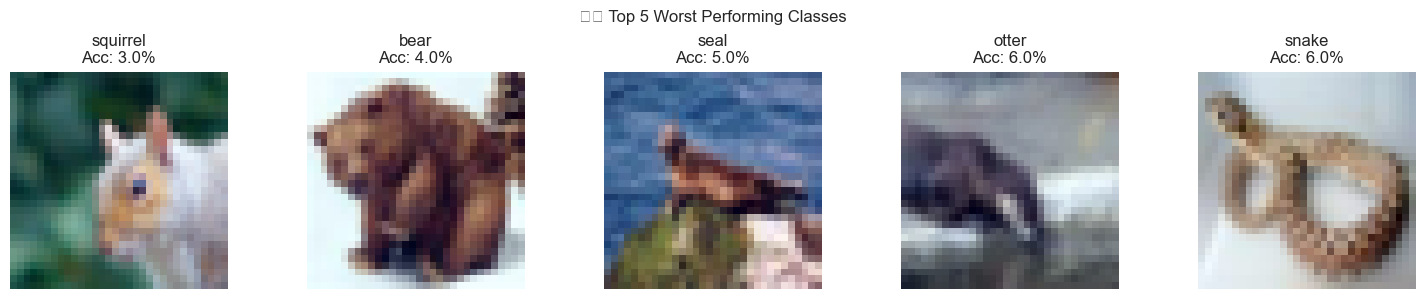

In [31]:
# TODO: Find Top 5 Best and Worst Performing Classes

import numpy as np
import matplotlib.pyplot as plt

def show_best_worst_classes(model, test_loader, classes, device=None):
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    model.to(device)

    num_classes = len(classes)

    correct_per_class = [0] * num_classes
    total_per_class = [0] * num_classes

    samples_per_class = {}

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for img, label, pred in zip(inputs, labels, preds):
                label = label.item()
                total_per_class[label] += 1
                if label == pred.item():
                    correct_per_class[label] += 1

                # فقط یک نمونه از هر کلاس
                if label not in samples_per_class:
                    samples_per_class[label] = img.cpu()

    acc_per_class = np.array([
        100 * c / t if t > 0 else 0
        for c, t in zip(correct_per_class, total_per_class)
    ])

    # TODO: Find Top 5 Best and Worst Performing Classes
    best_indices = np.argsort(-acc_per_class)[:5]  # Top 5
    worst_indices = np.argsort(acc_per_class)[:5]  # Bottom 5

    print("Top 5 Best Performing Classes:", best_indices)
    print("Top 5 Worst Performing Classes:", worst_indices)

    # TODO: Plot a Sample Image From Each of The Best and Worst Performing Classes
    def show_samples(indices, title):
        plt.figure(figsize=(15, 3))
        for i, idx in enumerate(indices):
            img = samples_per_class[idx]
            img = img.permute(1, 2, 0).numpy()
            img = (img - img.min()) / (img.max() - img.min())
            plt.subplot(1, 5, i + 1)
            plt.imshow(img)
            plt.title(f"{classes[idx]}\nAcc: {acc_per_class[idx]:.1f}%")
            plt.axis('off')
        plt.suptitle(title)
        plt.tight_layout()
        plt.show()

    show_samples(best_indices, "🔝 Top 5 Best Performing Classes")
    show_samples(worst_indices, "⚠️ Top 5 Worst Performing Classes")


show_best_worst_classes(model, test_loader, classes)



### Question
What do you think is the reason for the significant accuracy difference between different classes? What differences do you observe between the classes with the best and worst accuracy? Can you provide an analysis of the results and relate them to the model’s feature space?

Answer:تفاوت چشمگیر دقت بین کلاس‌ها معمولاً به تفاوت در ویژگی‌های بصری، تعداد نمونه‌ها، تنوع درون‌کلاسی، و شباهت بین‌کلاسی مربوط می‌شود. کلاس‌هایی با دقت بالا معمولاً دارای ویژگی‌های متمایز، بافت و شکل یکنواخت‌تر هستند (مثلاً وسایل نقلیه با فرم مشخص)، در حالی که کلاس‌های با دقت پایین ممکن است تنوع زیادی در ظاهر داشته باشند یا از نظر بصری با کلاس‌های دیگر اشتباه گرفته شوند (مثل حیوانات با شکل مشابه یا پس‌زمینه‌های پیچیده). این موضوع نشان می‌دهد که مدل در فضای ویژگی‌ها (feature space) برای برخی کلاس‌ها مرزهای تصمیم‌گیری واضحی یاد گرفته، ولی برای برخی دیگر به دلیل هم‌پوشانی یا پراکندگی داده‌ها، نتوانسته مرز مشخصی ترسیم کند. بنابراین، ضعف مدل در تمایز کلاس‌هایی با ویژگی‌های کم‌تمایز و توزیع نامتوازن، منجر به دقت پایین در آن‌ها می‌شود.